In [5]:
import os
import time
import json
import argparse
from dataclasses import asdict
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

In [6]:
os.chdir('..')

In [18]:
## Get all the training results
res_dir = 'Results/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
mean_errors = results_df.groupby(['model','sensor_count'])['error_u'].mean()
std_errors = results_df.groupby(['model','sensor_count'])['error_u'].std()
mean_nn = mean_errors['NN']
std_nn = std_errors['NN']
mean_linear = mean_errors['PINN']
std_linear = std_errors['PINN']

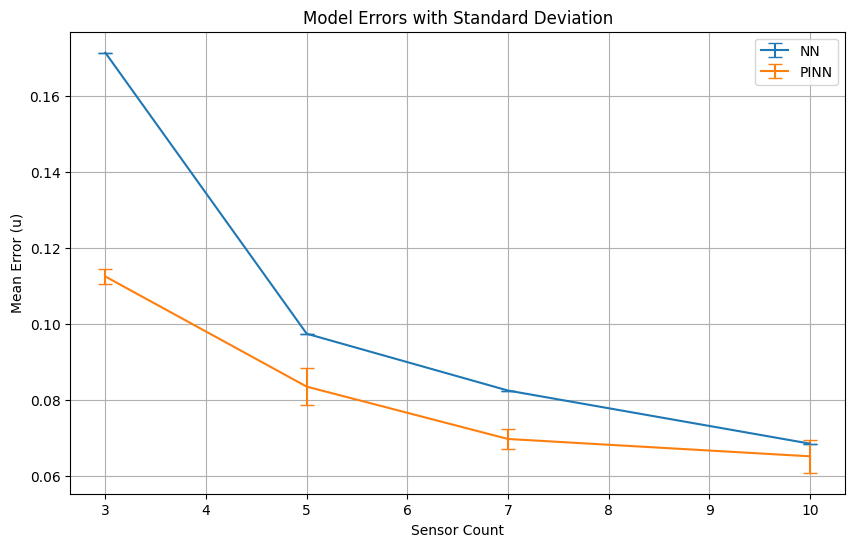

In [ ]:
# create a plot of the model errors with standard deviation as error bars
plt.figure(figsize=(10, 6))
for model in mean_errors.index.levels[0]:
    plt.errorbar(mean_errors[model].index, mean_errors[model], yerr=std_errors[model], label=model, capsize=5)
# plt.errorbar(mean_nn.index, mean_nn, yerr=std_nn, label='NN', capsize=5, fmt='o--', color='black')
plt.xlabel('Sensor Count')
plt.ylabel('Mean Error (u)')
plt.title('Model Errors with Standard Deviation')
plt.legend()
plt.grid()
plt.show()

In [21]:
## Get all the training results
res_dir = 'Results_FD/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
results_df = results_df[results_df['sensor_count']<11]
mean_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].mean()
std_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].std()

In [22]:
mean_errors

fd_name     sensor_count
exp         3               0.120031
            5               0.100527
            7               0.101066
            10              0.110622
linear      3               0.118317
            5               0.098590
            7               0.069792
            10              0.065230
log         3               0.106413
            5               0.093588
            7               0.083493
            10              0.090045
power       3               0.114869
            5               0.098074
            7               0.092448
            10              0.096493
triangular  3               0.129047
            5               0.115195
            7               0.126620
            10              0.126672
Name: error_u, dtype: float64

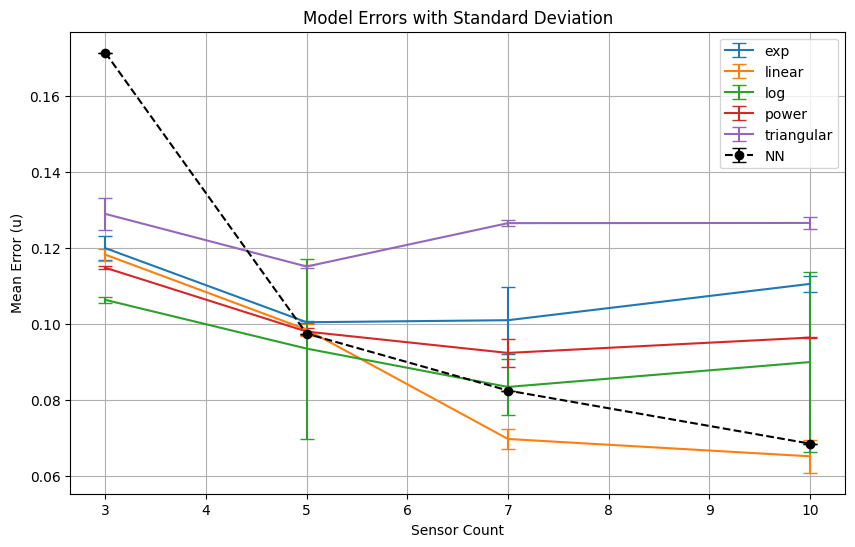

In [23]:
# create a plot of the model errors with standard deviation as error bars
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
for model in mean_errors.index.levels[0]:
    plt.errorbar(mean_errors[model].index, mean_errors[model], yerr=std_errors[model], label=model, capsize=5)
plt.errorbar(mean_nn.index, mean_nn, yerr=std_nn, label='NN', capsize=5, fmt='o--', color='black')
# plt.errorbar(mean_linear.index, mean_linear, yerr=std_linear, label='Linear', capsize=5, fmt='s--', color='blue')
plt.xlabel('Sensor Count')
plt.ylabel('Mean Error (u)')
plt.title('Model Errors with Standard Deviation')
plt.legend()
plt.grid()
plt.show()

In [8]:
## Get all the training results
res_dir = 'Results_1speed/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
results_df = results_df[results_df['sensor_count']<11]
mean_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].mean()
std_errors = results_df.groupby(['fd_name','sensor_count'])['error_u'].std()

In [9]:
## Get all the training results
res_dir = 'Results_2speed/summary/a13_multi_results.csv'
results_df = pd.read_csv(res_dir)
results_df = results_df[results_df['sensor_count']<11]
mean_errors2 = results_df.groupby(['fd_name','sensor_count'])['error_u'].mean()
std_errors2 = results_df.groupby(['fd_name','sensor_count'])['error_u'].std()

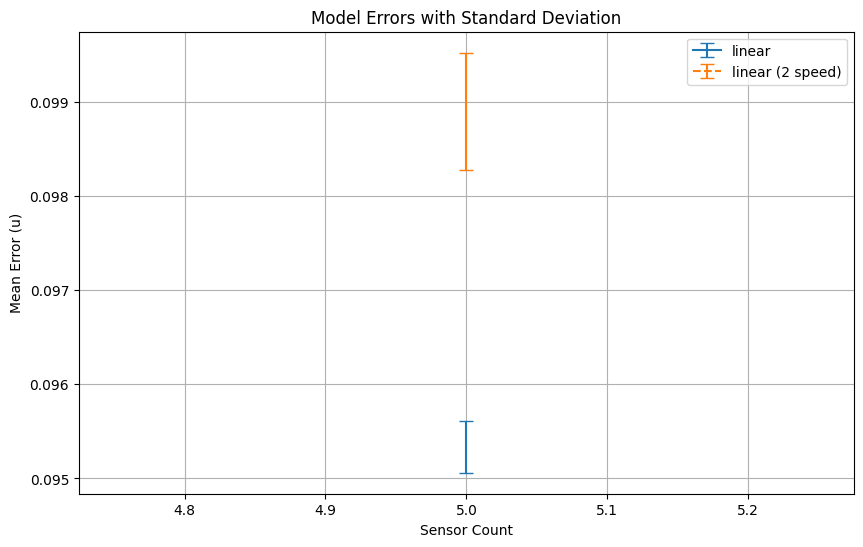

In [10]:
plt.figure(figsize=(10, 6))
for model in mean_errors.index.levels[0]:
    plt.errorbar(mean_errors[model].index, mean_errors[model], yerr=std_errors[model], label=model, capsize=5)

for model in mean_errors2.index.levels[0]:
    plt.errorbar(mean_errors2[model].index, mean_errors2[model], yerr=std_errors2[model], label=model+' (2 speed)', capsize=5, fmt='--')
# plt.errorbar(mean_linear.index, mean_linear, yerr=std_linear, label='Linear', capsize=5, fmt='s--', color='blue')
plt.xlabel('Sensor Count')
plt.ylabel('Mean Error (u)')
plt.title('Model Errors with Standard Deviation')
plt.legend()
plt.grid()
plt.show()

## Model

In [46]:
from utils import utils
from ojits03_a13_pytorch_revised import *

In [47]:
import importlib
importlib.reload(utils)
importlib.reload(ojits03_a13_pytorch_revised)

<module 'ojits03_a13_pytorch_revised' from '/baja/ojits03_a13_pytorch_revised.py'>

In [48]:
with open('configs/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f) or {}


In [49]:
data_file: str = cfg.get('data_file', 'data/A13_Velocity_Data_0909-0910.txt')
distance_json: str = cfg.get('distance_json', 'td_data/2024-09-09.json')
layers: List[int] = cfg.get('layers', [2, 20, 20, 20, 20, 20, 20, 20, 20, 1])
N_u: int = int(cfg.get('N_u', 800))
N_f: int = int(cfg.get('N_f', 10000))
sensor_based: bool = bool(cfg.get('sensor_based', False))
n_sensors: int = int(cfg.get('n_sensors', 5))
epochs: int = int(cfg.get('epochs', 10000))
lr: float = float(cfg.get('lr', 1e-4))
log_every: int = int(cfg.get('log_every', 200))
physics_every: int = int(cfg.get('physics_every', 1))
patience: int = int(cfg.get('patience', 2000))
seed: int = int(cfg.get('seed', 25))
out_fig_dir: str = cfg.get('out_fig_dir', 'figures_revised2')
fast: bool = bool(cfg.get('fast', False))
f_weight: float = float(cfg.get('f_weight', 1.0))
fd_name: str = cfg.get('fd_name', 'linear')
run_base: bool = bool(cfg.get('run_base', True))

In [50]:
data_file

'data/A13_Velocity_Data_0909-0913.txt'

In [64]:
# Load data
vel = load_velocity_table(data_file)
print(f"A13 Data Shape: {vel.shape}")
print(f"Spatial locations: {vel.shape[0]}")
print(f"Time steps: {vel.shape[1]}")

x = load_distances(distance_json, n_locations_hint=vel.shape[0])
t = np.arange(vel.shape[1]).reshape(-1, 1)

Exact = np.real(vel.T)
X, T, X_star = build_space_time_grid(x, t)
idx_grid = build_index_grid(Exact, t)
u_star = Exact.flatten()[:, None]

# Fill missing
u_star, n_missing, u_mean = replace_missing_with_mean(u_star)
if n_missing > 0:
    print(f"Replaced {n_missing} missing values with mean: {u_mean:.2f}")

# Bounds
lb = X_star.min(0).astype(np.float32)
ub = X_star.max(0).astype(np.float32)

# Select training points
n_locations = x.shape[0]
n_timesteps = t.shape[0]
if sensor_based:
    print("\n[Data Selection] Using sensor-based column selection (equally distributed)")
    X_u_train, u_train, idx_train, n_valid, sensors, sensor_point_counts = select_sensor_columns(
        u_star, X_star, n_locations, n_timesteps, 1000
    )
    print(f"  - Total available locations: {n_locations}")
    print(f"  - Requested sensors: {n_sensors}")
    print(f"  - Selected sensors: {len(sensors)} (equally spaced)")
    print(f"  - Sensor indices: {sensors}")
    print(f"  - Total observation points: {n_valid}")
    for col, n_pts in sensor_point_counts:
        print(f"    · Sensor {col}: {n_pts} points")
    n_sensors_to_select = len(sensors)
else:
    print("\n[Data Selection] Using random sampling from all valid points")
    X_u_train, u_train, idx_train, n_valid = select_random_points(X_star, idx_grid, u_star, N_u)
    print(f"  - Sampled points: {n_valid}")
    n_sensors_to_select = None

# Collocation points
X_f_train = make_collocation(lb, ub, N_f, X_u_train)
print(f"\nTraining with {n_valid} data points (+ {N_f} collocation points)")

A13 Data Shape: (29, 480)
Spatial locations: 29
Time steps: 480

[Data Selection] Using sensor-based column selection (equally distributed)
  - Total available locations: 29
  - Requested sensors: 5
  - Selected sensors: 29 (equally spaced)
  - Sensor indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
  - Total observation points: 13920
    · Sensor 0: 480 points
    · Sensor 1: 480 points
    · Sensor 2: 480 points
    · Sensor 3: 480 points
    · Sensor 4: 480 points
    · Sensor 5: 480 points
    · Sensor 6: 480 points
    · Sensor 7: 480 points
    · Sensor 8: 480 points
    · Sensor 9: 480 points
    · Sensor 10: 480 points
    · Sensor 11: 480 points
    · Sensor 12: 480 points
    · Sensor 13: 480 points
    · Sensor 14: 480 points
    · Sensor 15: 480 points
    · Sensor 16: 480 points
    · Sensor 17: 480 points
    · Sensor 18: 480 points
    · Sensor 19: 480 points
    · Sensor 20: 480 points
    · Sensor 21: 4

In [82]:
Exact.shape

(480, 29)

In [91]:
I think I messed up my free-flow speed limits,
I want to find these out from data. Suppose I have a amtrix of speeds. Its sahpe is (480,29), where there is 480 time aggregartions by 15 min, and 29 locations. 
The specific times/locations can be found in vector T (T,1) and x (X,1). I briefly plotted the histograms for each of 29 dimensions and I notice large variations in the central speed - and the limits
Propose a way to automatically decide what the speed limit is for the given location. Return a dictionary (or actually return whater format you want but keep in mind we weill use
                                                                                                           these findings to adust the loss function).

SyntaxError: invalid syntax (3738615647.py, line 1)

Mean|Max velocity at location 6.4: 74.27|80.98


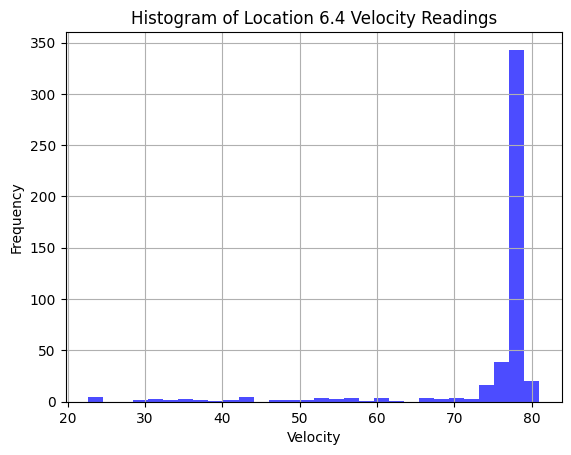

Mean|Max velocity at location 6.725: 69.26|77.79


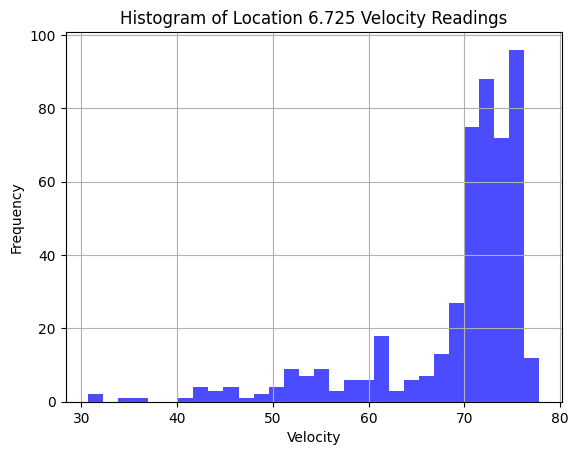

Mean|Max velocity at location 7.2: 71.08|78.72


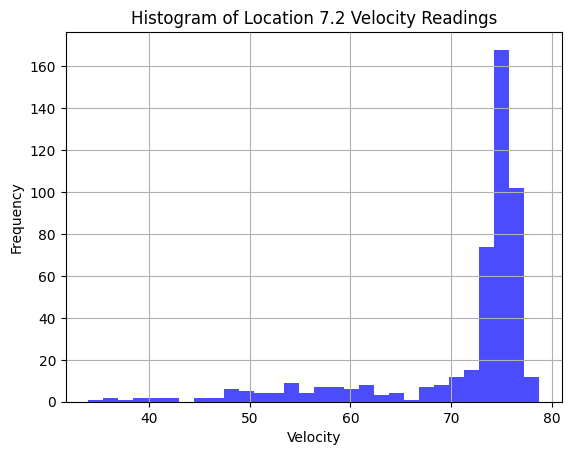

Mean|Max velocity at location 7.65: 70.91|79.73


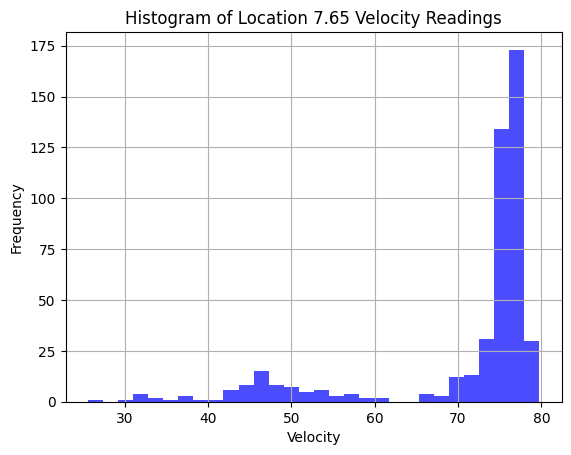

Mean|Max velocity at location 8.1: 74.74|87.76


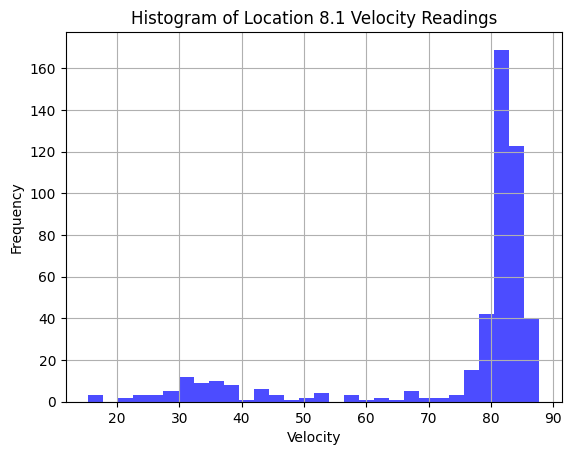

Mean|Max velocity at location 8.6: 77.79|92.23


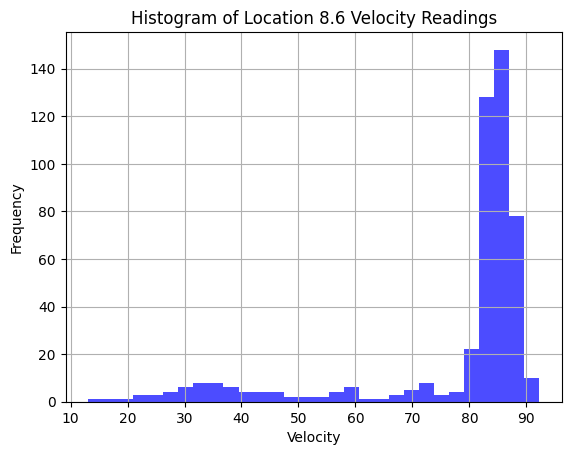

Mean|Max velocity at location 9.1: 83.58|96.86


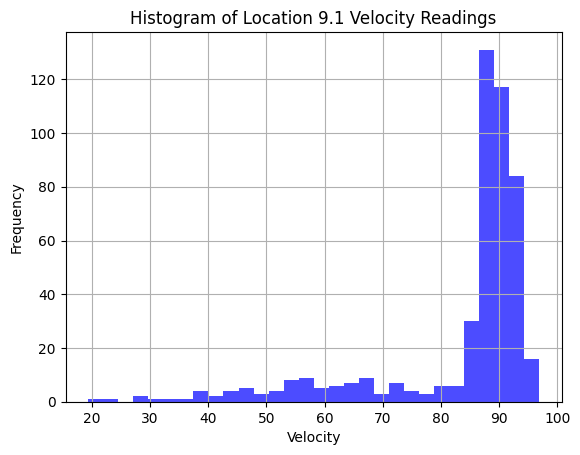

Mean|Max velocity at location 9.5: 92.15|120.39


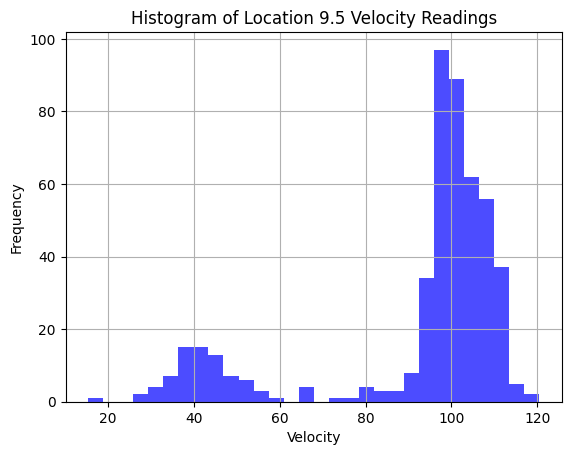

Mean|Max velocity at location 9.9: 94.60|110.08


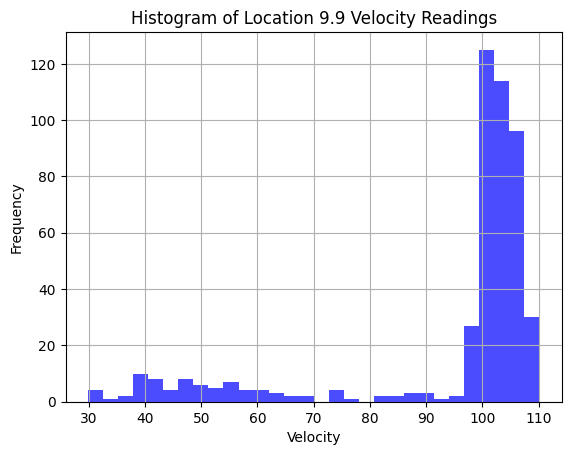

Mean|Max velocity at location 10.3: 95.17|111.19


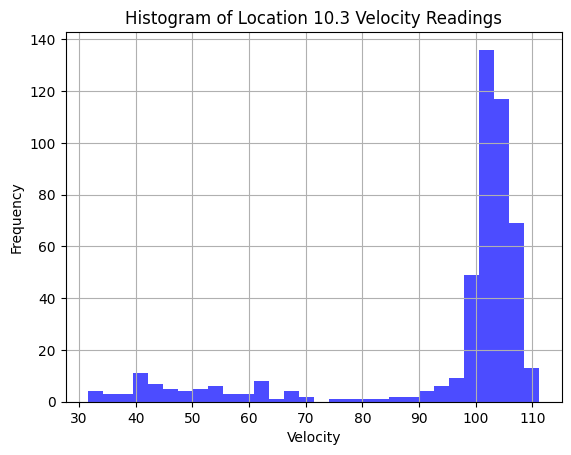

Mean|Max velocity at location 10.7: 93.80|108.68


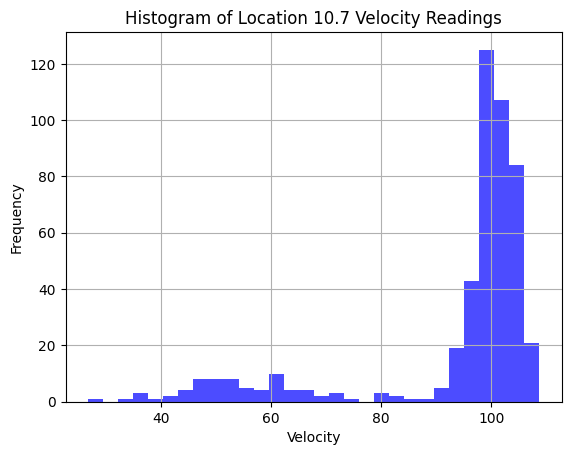

Mean|Max velocity at location 11.1: 96.15|114.49


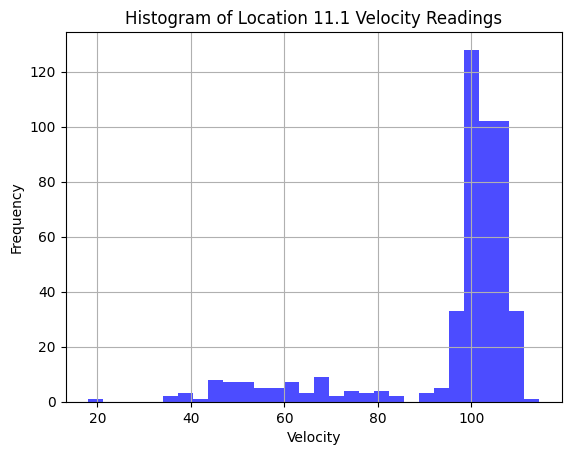

Mean|Max velocity at location 11.5: 95.84|112.37


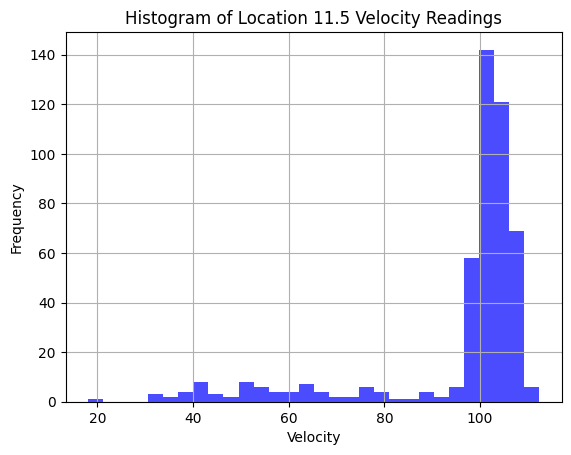

Mean|Max velocity at location 11.966: 92.30|106.09


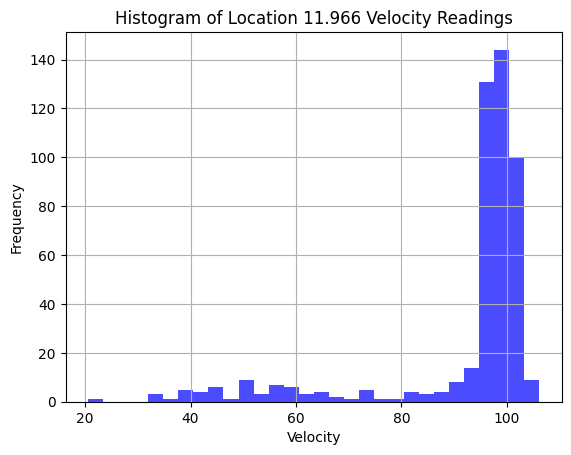

Mean|Max velocity at location 12.274: 94.78|112.40


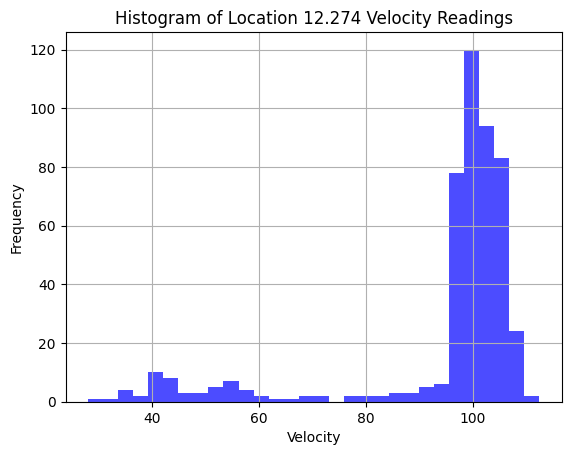

Mean|Max velocity at location 12.7: 95.68|114.23


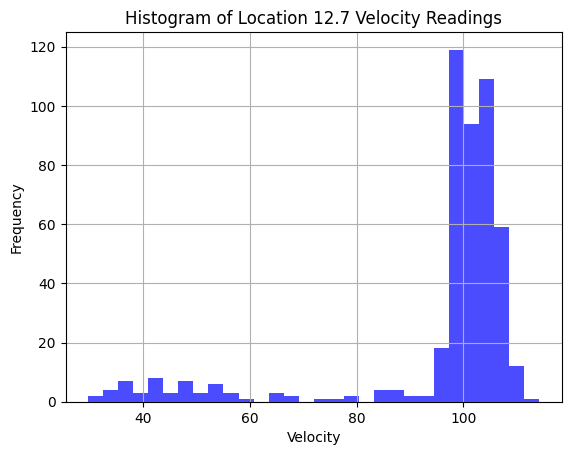

Mean|Max velocity at location 13.2: 97.99|114.22


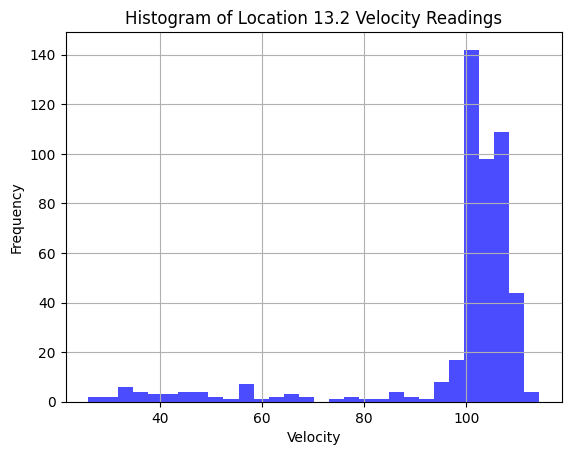

Mean|Max velocity at location 13.7: 99.50|113.07


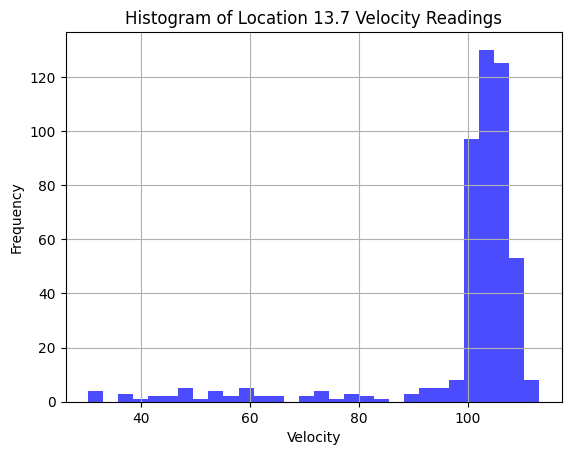

Mean|Max velocity at location 14.38: 104.89|123.02


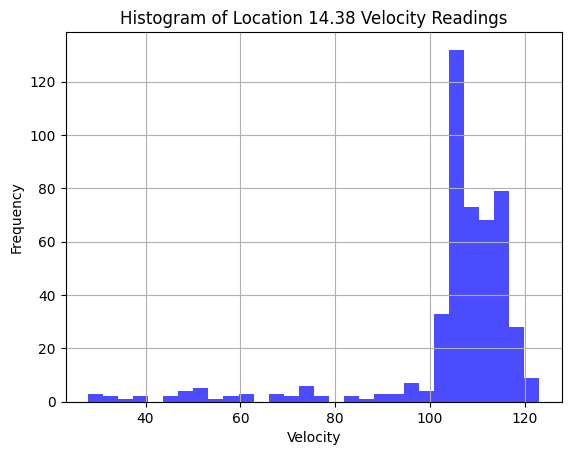

Mean|Max velocity at location 14.7: 101.25|112.85


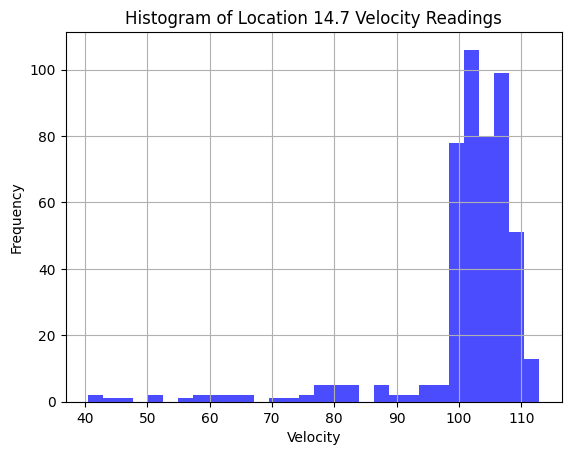

Mean|Max velocity at location 15.035: 99.59|111.74


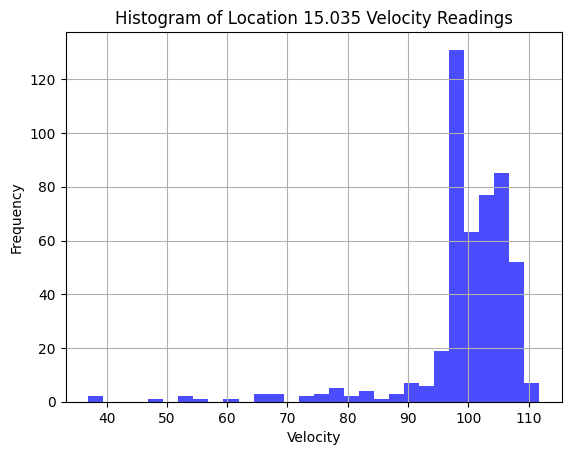

Mean|Max velocity at location 15.55: 100.98|112.20


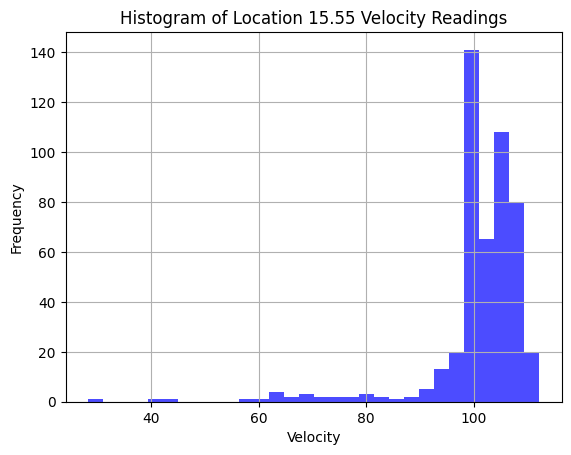

Mean|Max velocity at location 16.2: 102.19|113.46


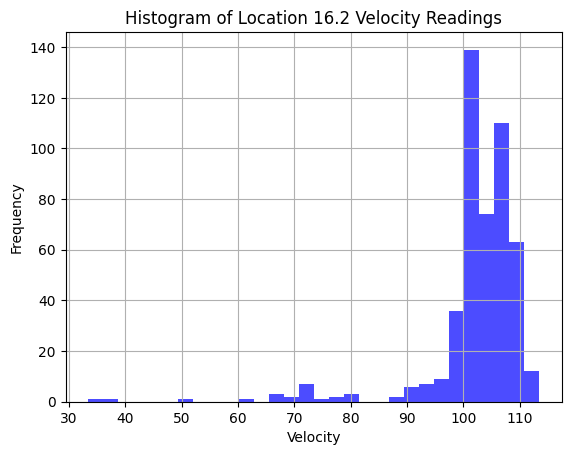

Mean|Max velocity at location 16.5: 101.24|112.49


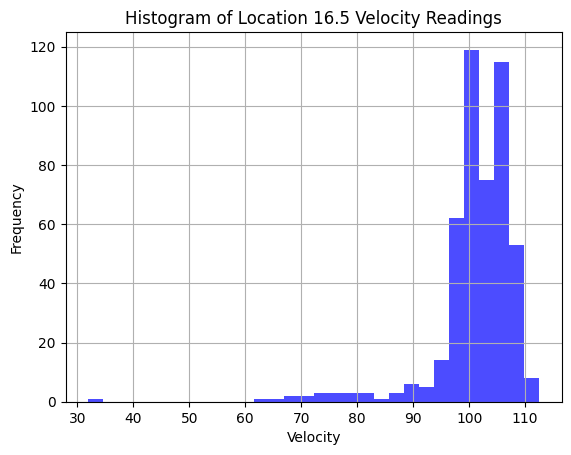

Mean|Max velocity at location 16.69: 100.54|112.80


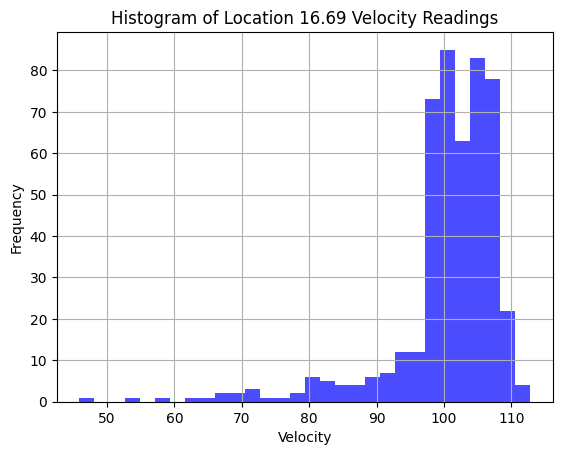

Mean|Max velocity at location 17.1: 99.16|109.77


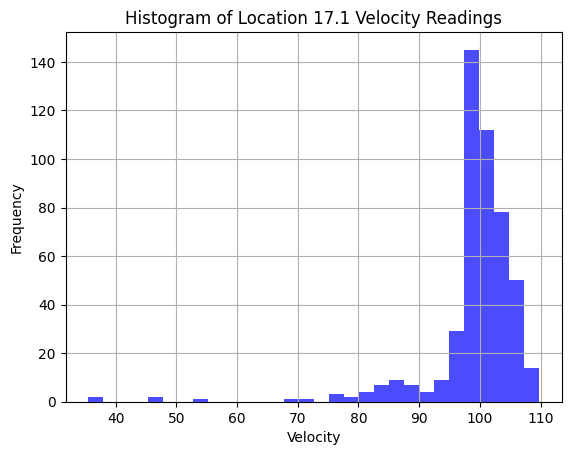

Mean|Max velocity at location 17.4: 97.59|112.21


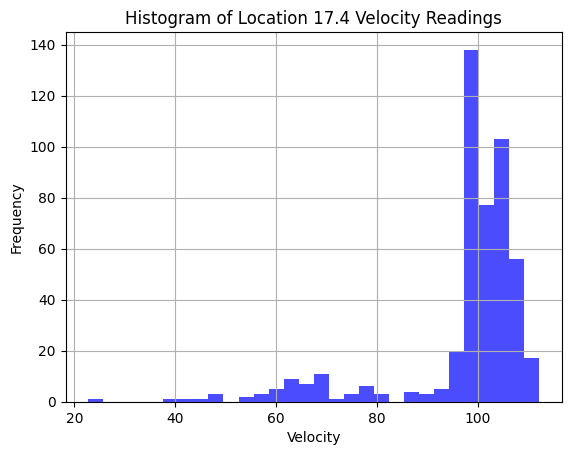

Mean|Max velocity at location 17.8: 97.47|111.77


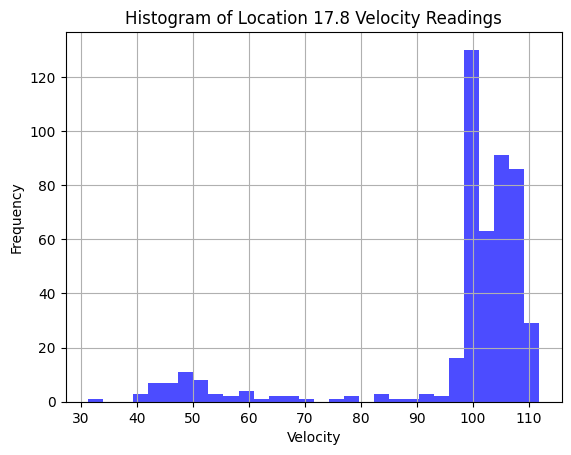

Mean|Max velocity at location 18.2: 95.44|108.82


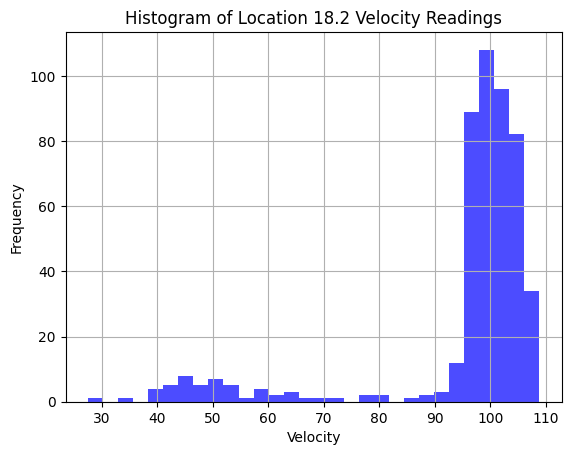

In [89]:
for col in range(Exact.shape[1]):
    data_to_hist = Exact[:,col]
    print(f'Mean|Max velocity at location {x[col][0]}: {np.mean(data_to_hist):.2f}|{np.max(data_to_hist):.2f}')

    plt.figure()
    plt.hist(data_to_hist, bins=30, alpha=0.7, color='blue')
    plt.title(f'Histogram of Location {x[col][0]} Velocity Readings')
    plt.xlabel('Velocity')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()
    

In [95]:
import numpy as np
import pandas as pd

def infer_speed_limits(U: np.ndarray, x: np.ndarray,
                       valid_limits=(80, 100),
                       perc=95) -> pd.DataFrame:
    """
    Infer per-location free-flow speed limit from a speed matrix.

    Parameters
    ----------
    U : array (Nt, Nx)
        Speed matrix (km/h). Each column is one location.
    x : array (Nx,) or (Nx,1)
        Location coordinates (e.g., km markers).
    valid_limits : tuple
        Allowed discrete speed limits.
    perc : int
        Percentile to use for the free-flow estimate.

    Returns
    -------
    pd.DataFrame with columns ['x', 'v_free_est', 'limit_assigned'].
    """

    x = np.squeeze(x)
    n_loc = U.shape[1]
    v_est = []
    v_assign = []

    for j in range(n_loc):
        u_col = np.asarray(U[:, j], dtype=float)
        u_col = u_col[np.isfinite(u_col) & (u_col > 0)]
        if len(u_col) == 0:
            v_est.append(np.nan)
            v_assign.append(np.nan)
            continue
        v_p = np.percentile(u_col, perc)
        v_est.append(v_p)
        # choose closest allowed limit
        v_assign.append(min(valid_limits, key=lambda v: abs(v_p - v)))

    df = pd.DataFrame({
        "x": x,
        f"v{perc}_est": v_est,
        "limit_assigned": v_assign
    })
    return df


In [1]:
import numpy as np
import pandas as pd

def _majority_vote_1d(values, window=3):
    """Simple majority vote over a centered window. Works on small integer sets like {80, 100}."""
    if window is None or window <= 1:
        return list(values)
    arr = np.asarray(values)
    n = len(arr)
    out = []
    for i in range(n):
        L = max(0, i - window // 2)
        R = min(n, i + window // 2 + 1)
        sub = arr[L:R]
        vals, counts = np.unique(sub, return_counts=True)
        out.append(vals[np.argmax(counts)])
    return out

def infer_speed_limits_chunked(
    U: np.ndarray,           # shape (Nt, Nx), km h
    x: np.ndarray,           # shape (Nx,) or (Nx,1), location coordinate
    T: np.ndarray,           # shape (Nt,) or (Nt,1), time coordinate or index
    chunk_hours: float = 0,  # 0 means ignore time, do per location only
    interval_minutes: float = 15.0,
    perc: float = 95.0,      # percentile for free flow tail
    valid_limits=(80, 100),
    smooth_space_window: int | None = None,  # optional majority vote across neighboring locations inside each chunk
    smooth_time_window: int | None = None    # optional majority vote across neighboring chunks for each location
) -> tuple[pd.DataFrame, dict]:
    """
    Returns a DataFrame with columns:
        ['chunk_id','t_start','t_end','x','v_est','limit_assigned']
    and a dictionary mapping (chunk_id, x_value) -> limit.
    """

    # prepare shapes
    U = np.asarray(U, dtype=float)
    x = np.squeeze(np.asarray(x))
    T = np.squeeze(np.asarray(T))
    Nt, Nx = U.shape
    assert Nx == x.shape[0], "x length must match number of columns in U"
    assert T.shape[0] == Nt, "T length must match number of rows in U"

    # decide chunking
    if chunk_hours and chunk_hours > 0:
        steps_per_hour = 60.0 / float(interval_minutes)
        steps_per_chunk = int(max(1, round(chunk_hours * steps_per_hour)))
        n_chunks = int(np.ceil(Nt / steps_per_chunk))
        bounds = [(i * steps_per_chunk, min((i + 1) * steps_per_chunk, Nt)) for i in range(n_chunks)]
    else:
        n_chunks = 1
        bounds = [(0, Nt)]

    rows = []

    # main loop over time chunks
    for cid, (t0, t1) in enumerate(bounds):
        Ublock = U[t0:t1, :]                           # time slice
        # remove invalids per location, compute percentile
        v_est = []
        for j in range(Nx):
            col = Ublock[:, j]
            col = col[np.isfinite(col) & (col > 0)]
            if col.size == 0:
                v_est.append(np.nan)
            else:
                v_est.append(np.percentile(col, perc))
        v_est = np.array(v_est, dtype=float)

        # assign to nearest allowed limit
        assign = []
        for val in v_est:
            if not np.isfinite(val):
                assign.append(np.nan)
            else:
                assign.append(min(valid_limits, key=lambda v: abs(val - v)))
        assign = np.array(assign)

        # optional spatial smoothing inside this chunk
        if smooth_space_window and smooth_space_window > 1:
            mask = np.isfinite(assign)
            if mask.any():
                smoothed = np.array(_majority_vote_1d(assign[mask], window=smooth_space_window))
                assign[mask] = smoothed

        # stash rows
        t_start = float(T[t0])
        t_end = float(T[t1 - 1])
        for j in range(Nx):
            rows.append({
                "chunk_id": cid,
                "t_start": t_start,
                "t_end": t_end,
                "x": float(x[j]),
                "v_est": float(v_est[j]) if np.isfinite(v_est[j]) else np.nan,
                "limit_assigned": int(assign[j]) if np.isfinite(assign[j]) else np.nan
            })

    df = pd.DataFrame(rows)

    # optional temporal smoothing across chunks for each location
    if smooth_time_window and smooth_time_window > 1 and n_chunks > 1:
        df = df.sort_values(["x", "chunk_id"]).reset_index(drop=True)
        out_limits = []
        for xv, grp in df.groupby("x", sort=False):
            sm = _majority_vote_1d(grp["limit_assigned"].values, window=smooth_time_window)
            out_limits.extend(sm)
        df["limit_assigned"] = out_limits

    # build dictionary for direct use in loss functions
    limit_dict = {(int(r.chunk_id), float(r.x)): int(r.limit_assigned) for r in df.itertuples() if np.isfinite(r.limit_assigned)}

    return df, limit_dict


In [4]:
# per location only
df_loc, vf_map_loc = infer_speed_limits_chunked(Exact, x, t, chunk_hours=0, perc=95)

# # per location and per 8 hour chunk, with mild smoothing
# df_time, vf_map_time = infer_speed_limits_chunked(
#     U, x, T,
#     chunk_hours=8,
#     perc=95,
#     smooth_space_window=3,
#     smooth_time_window=3
# )

NameError: name 'Exact' is not defined

In [69]:
t.shape

(480, 1)

In [68]:
29*480

13920

In [83]:
U_train_sensor.shape

(29, 480)

In [70]:
U_train_sensor = u_train.reshape(x.shape[0],t.shape[0])

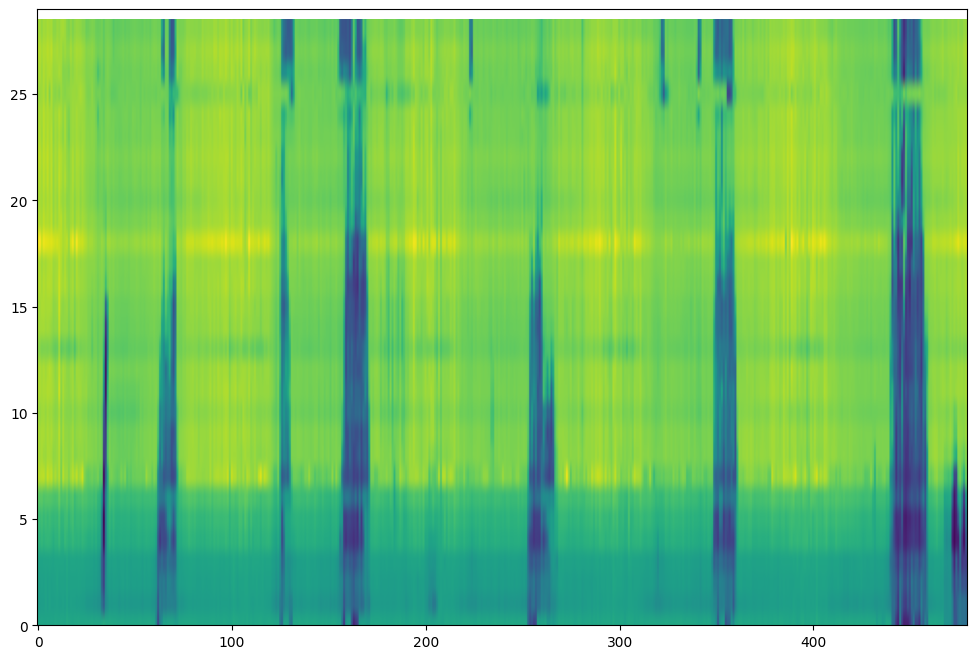

In [80]:
fig = plt.figure(figsize=(12,8))
plt.imshow(U_train_sensor, aspect='auto', cmap='viridis')
# make the y axis start at 0 and go up
plt.ylim(0, U_train_sensor.shape[0])
plt.show()

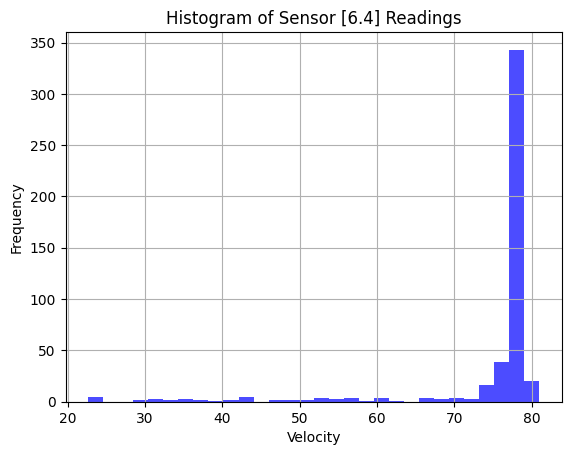

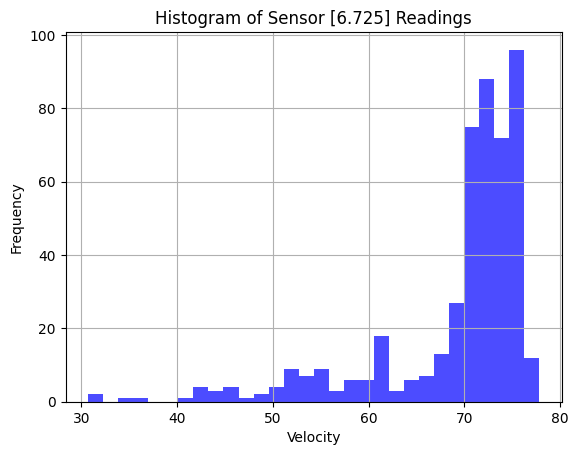

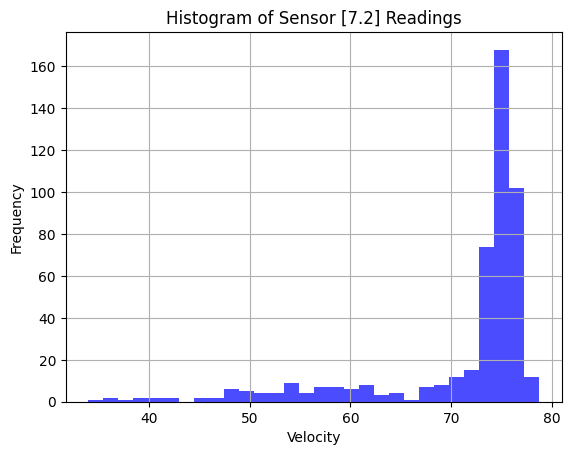

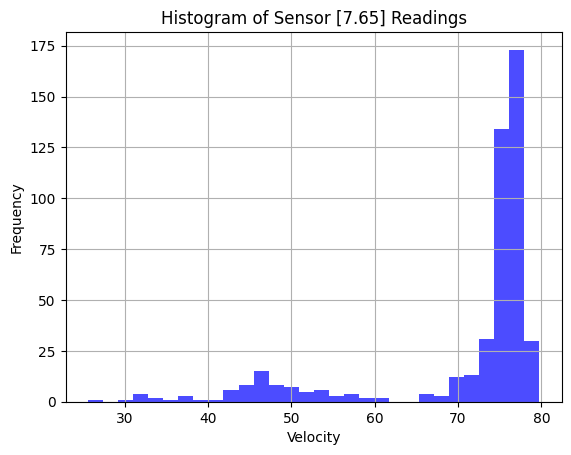

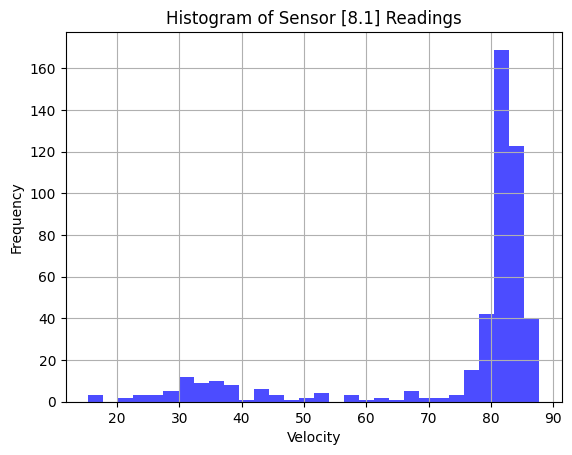

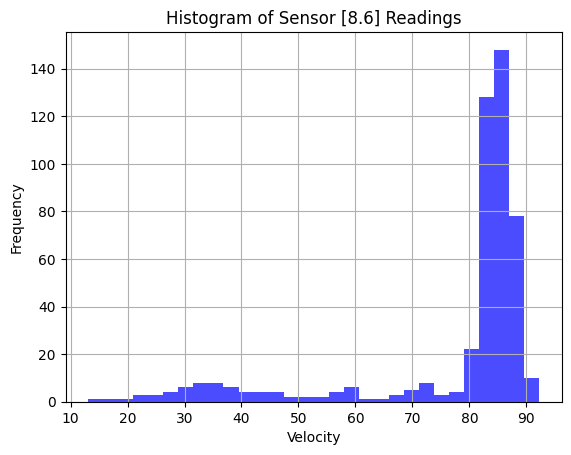

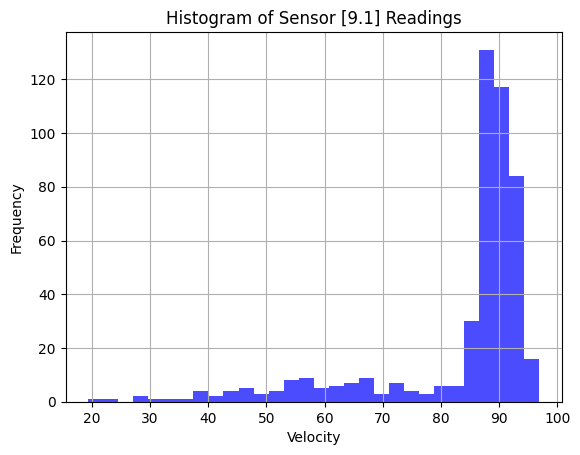

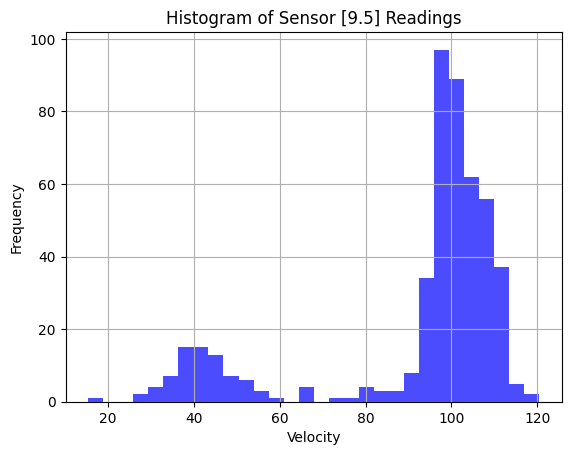

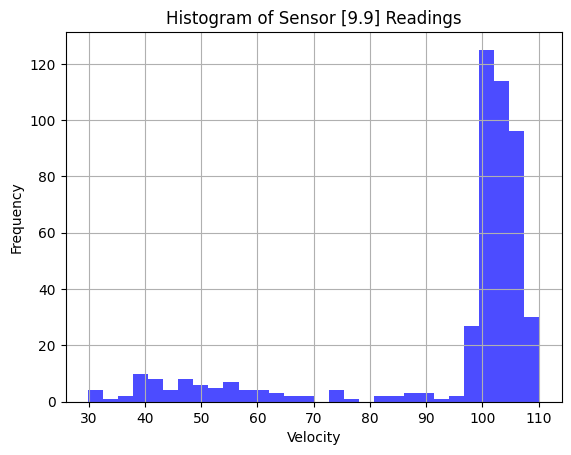

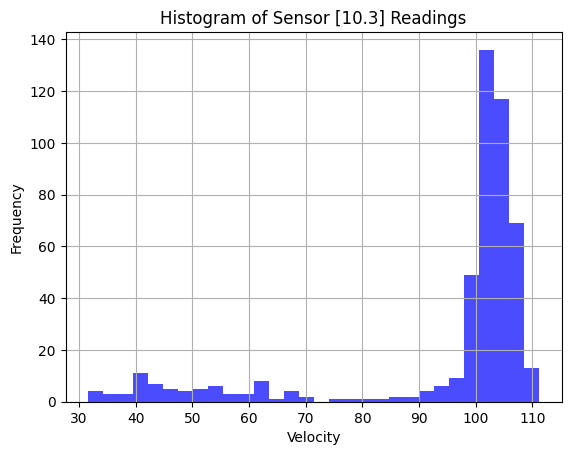

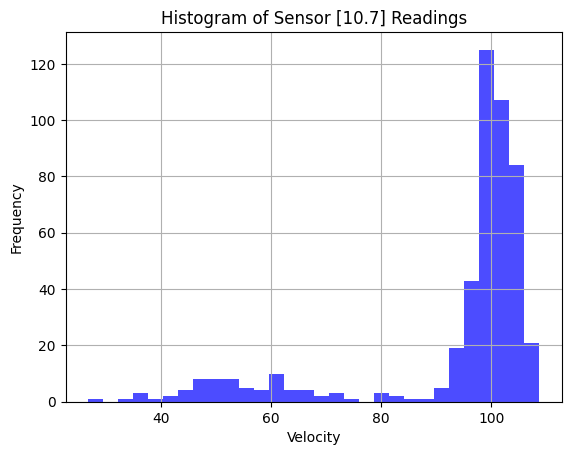

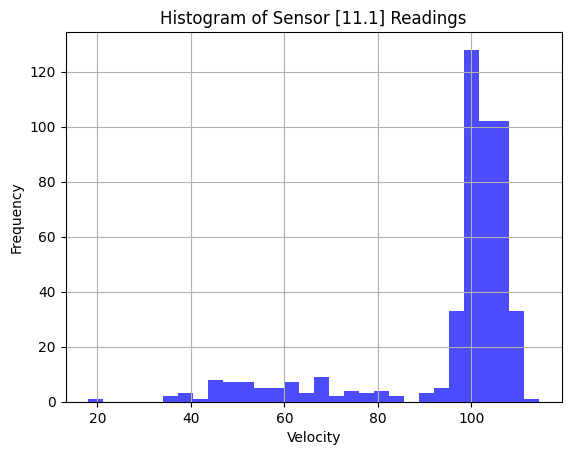

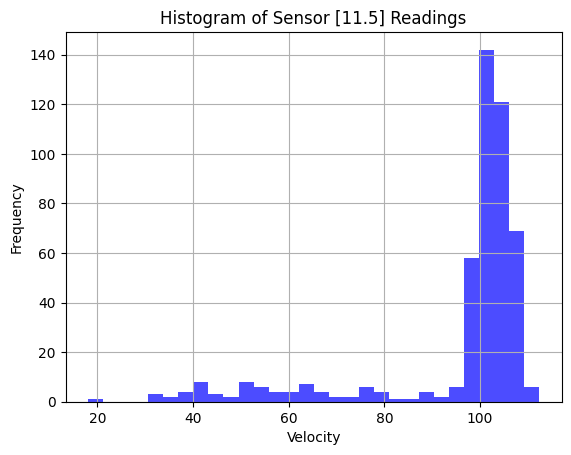

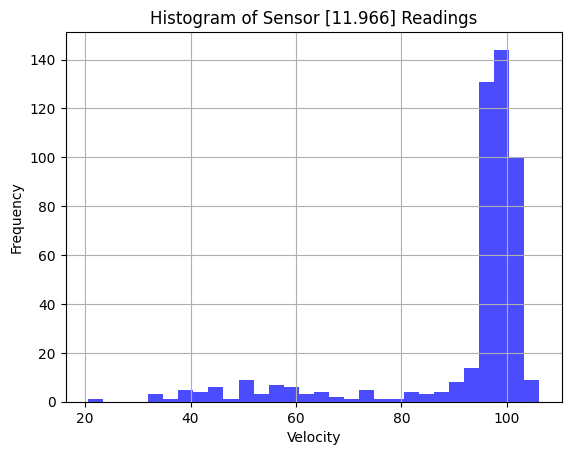

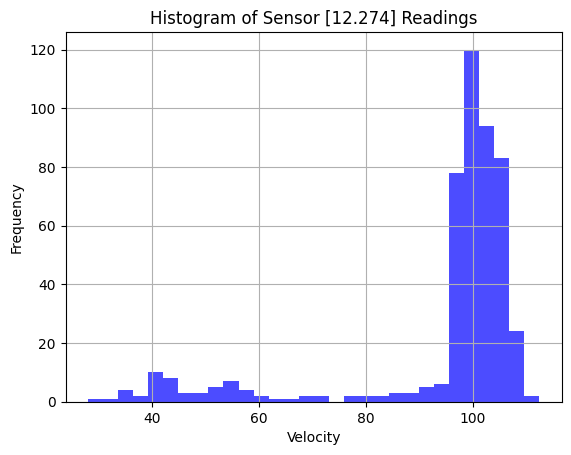

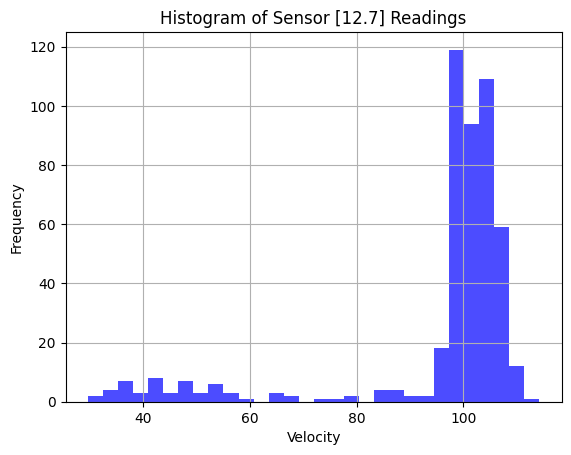

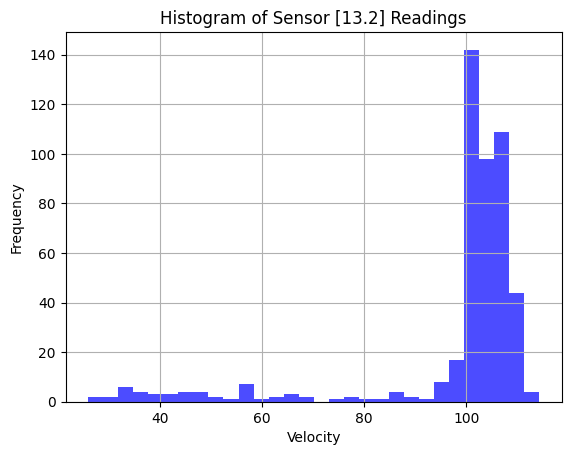

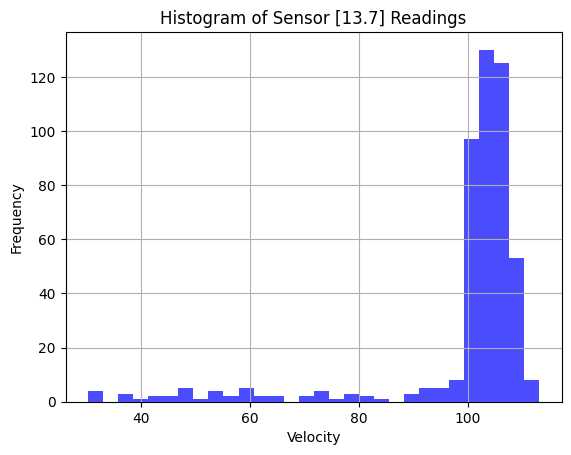

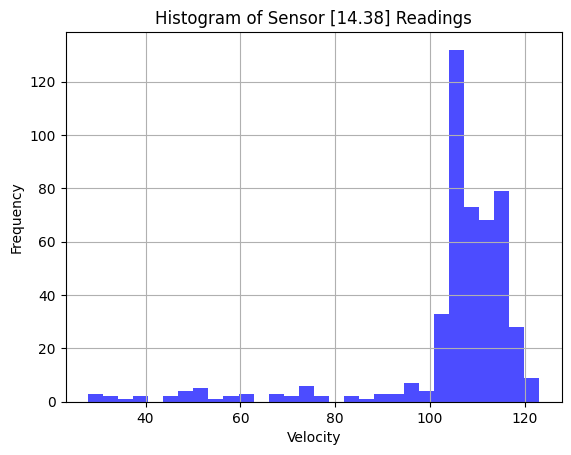

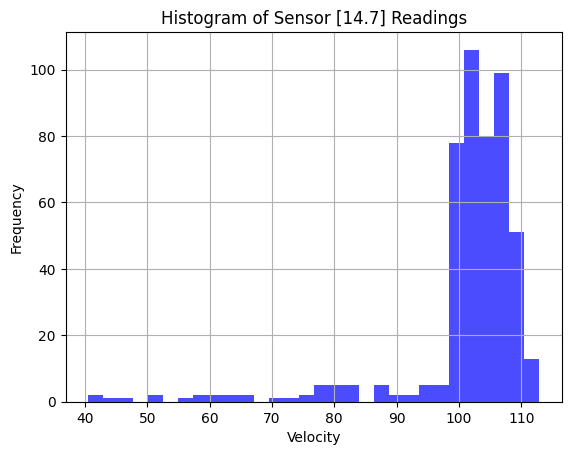

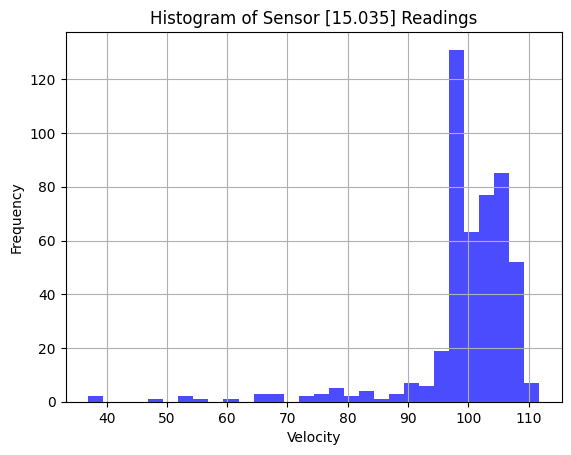

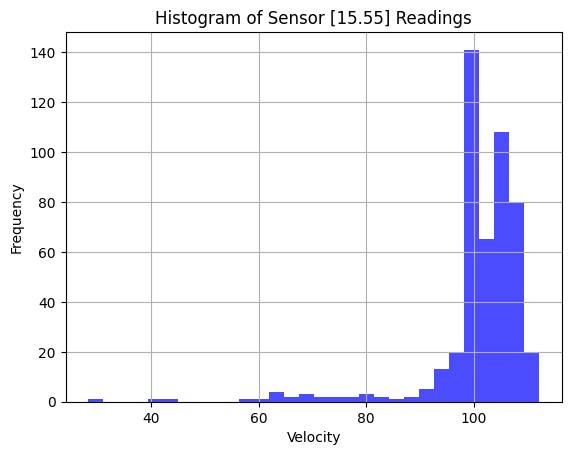

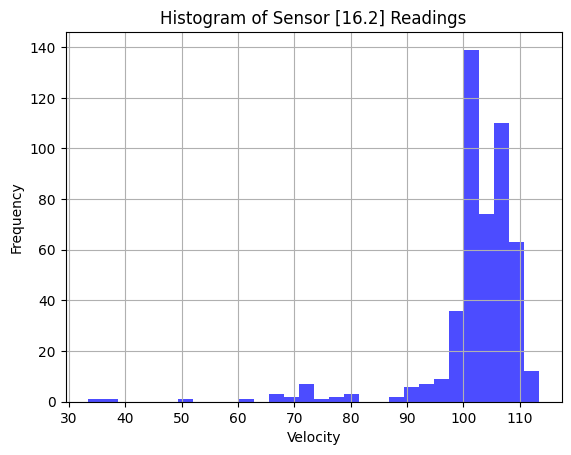

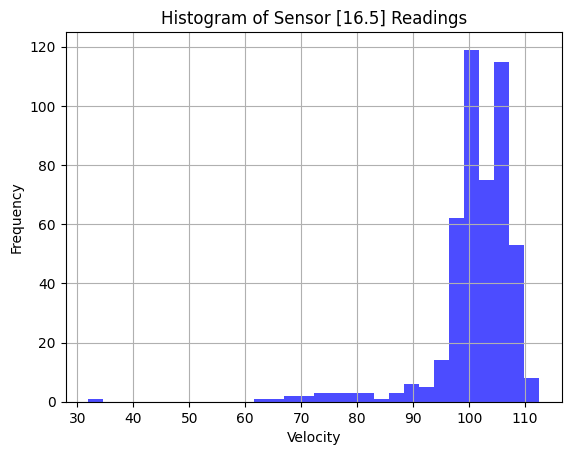

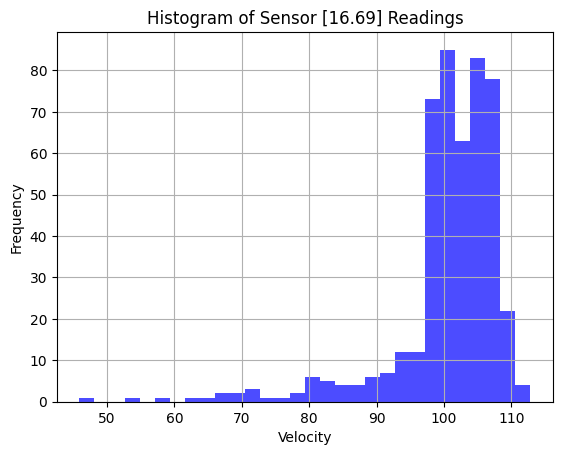

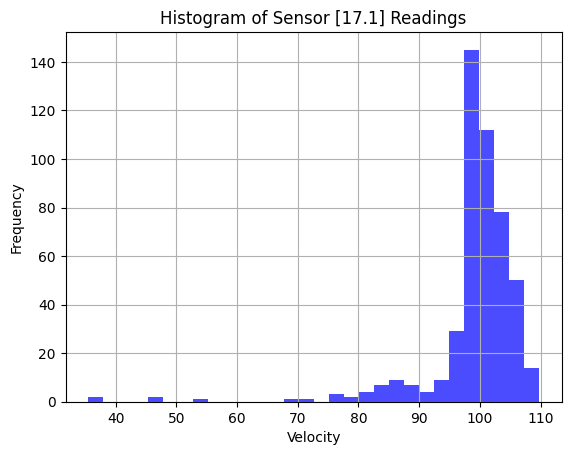

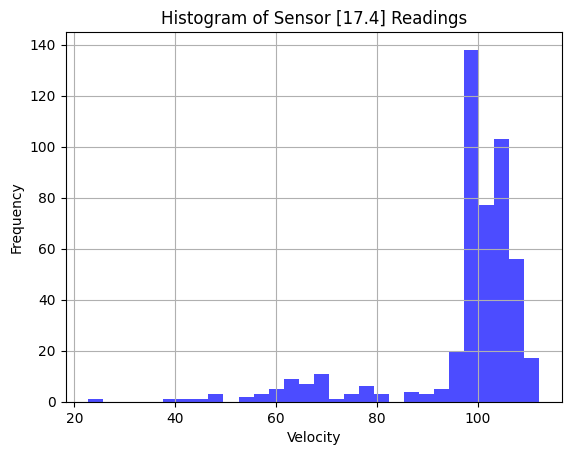

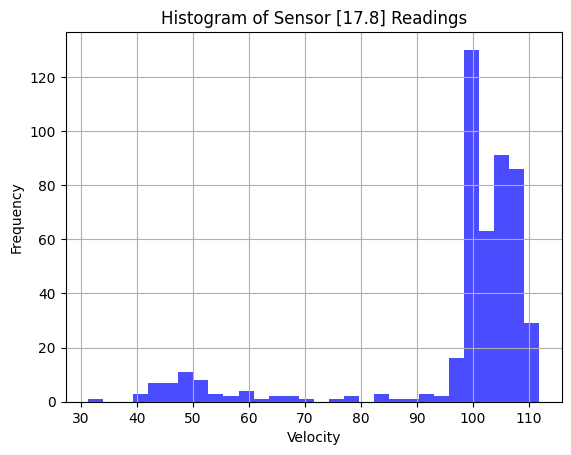

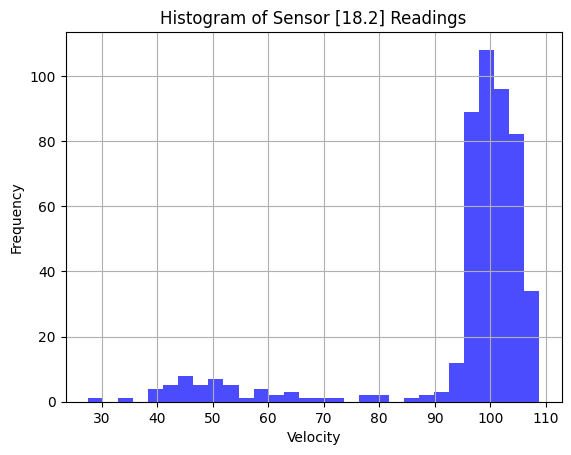

In [73]:
# create a histogram per sensor
for i in range(U_train_sensor.shape[0]):
    plt.figure()
    plt.hist(U_train_sensor[i,:], bins=30, alpha=0.7, color='blue')
    plt.title(f'Histogram of Sensor {x[i]} Readings')
    plt.xlabel('Velocity')
    plt.ylabel('Frequency')
    plt.grid()
    plt.show()

(array([  1.,   5.,  11.,  21.,  46.,  50.,  33.,  35.,  20.,  21.,  18.,
        289., 155.,  14.,  46., 505., 657., 412.,  58.,   3.]),
 array([ 15.45 ,  20.697,  25.944,  31.191,  36.438,  41.685,  46.932,
         52.179,  57.426,  62.673,  67.92 ,  73.167,  78.414,  83.661,
         88.908,  94.155,  99.402, 104.649, 109.896, 115.143, 120.39 ]),
 <BarContainer object of 20 artists>)

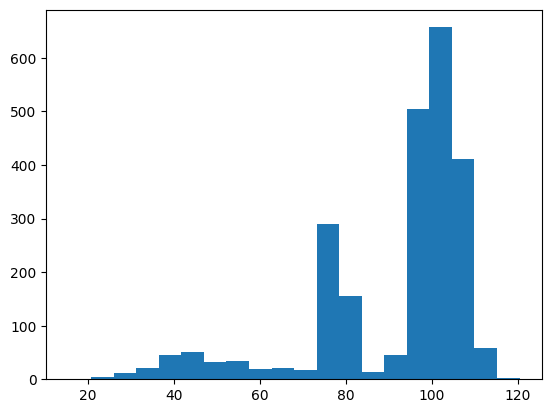

In [58]:
plt.hist(u_train, bins=20)

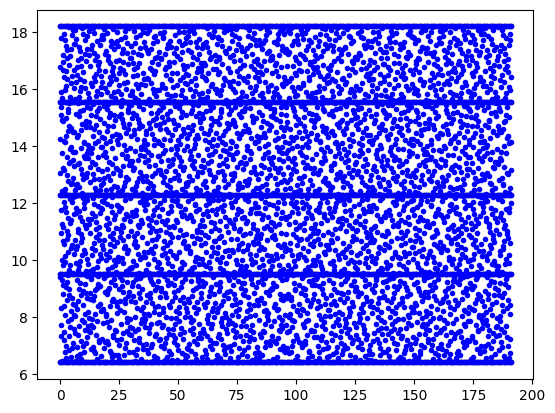

In [22]:
plt.plot(X_u_train[:, 1], X_u_train[:, 0], 'k.')
plt.plot(X_f_train[:, 1], X_f_train[:, 0], 'b.')

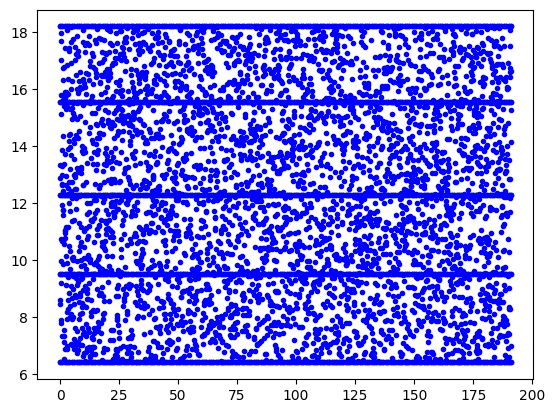

In [44]:
plt.plot(X_u_train[:, 1], X_u_train[:, 0], 'k.')
plt.plot(X_f_train[:, 1], X_f_train[:, 0], 'b.')